In [ ]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

In [3]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
from scipy.spatial.distance import cdist
import xarray as xr

import sys

from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()


def gaussian_model(x, mu, sigma):
    y = np.exp(-0.5 * (x - mu) ** 2 / sigma**2)
    return y / np.max(y)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

/tmp/ipykernel_571790/407698957.py:33: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


# Refactored Code Example Using New Interface

This section demonstrates how to run the same 3-camera comparison using the new refactored `test_simulation_method()` interface with proper parameter validation and configuration management.

In [4]:
# Import the new refactored classes
from pyS3M.Multicolour_Simulation_Functions import (
    FittingStrategy,
    CameraParameters,
    SimulationConfig,
)

print("Imported new refactored classes successfully!")
print("Available fitting strategies:", [strategy.value for strategy in FittingStrategy])

Imported new refactored classes successfully!
Available fitting strategies: ['standard', 'standard_iter', 'demosaic', 'demosaic_fast', 'demosaic_ig', 'standard_ig']


In [5]:
# data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = "../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [6]:
image_size = 10
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

camera_parameters_dict = {
    "gain": np.full((image_size, image_size), np.median(gain)),
    "offset": np.full((image_size, image_size), np.median(offset)),
    "variance": np.full((image_size, image_size), np.median(variance)),
    "readnoise": np.full((image_size, image_size), np.median(readnoise)),
    "rqe": np.full((image_size, image_size), np.median(rqe)),
    "masks": masks,
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": {
        "B": 0,
        "G": 1,
        "R": 2,
    },  # Fixed to use dict instead of list
}


In [38]:
dye = "ATTO 488"
n_photons = {}
n_photon = 4000
n_photons[dye] = np.full(1, n_photon)
pixel_size = 69
dye_matrix = np.zeros([1, len(wavelength)])
filters = []
x0y0 = {}
max = pixel_size * image_size

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
NA = 1.49
x0 = 4.75 * pixel_size
y0 = 4.75 * pixel_size
for dye in n_photons:
    x0y0[dye] = np.zeros([1, 2, 1])
    x0y0[dye][:, :, :] = np.array([[y0, x0]]).T

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
n_background = 4
image_ATTO488, _, _ = MSF.gen_camera_image_stack(
    camera_parameters_dict,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

In [39]:
dye = "ATTO 565"
n_photons = {}
n_photon = 4000
n_photons[dye] = np.full(1, n_photon)
pixel_size = 69
dye_matrix = np.zeros([1, len(wavelength)])
filters = []
x0y0 = {}
max = pixel_size * image_size

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
NA = 1.49
x0 = 4.75 * pixel_size
y0 = 4.75 * pixel_size
for dye in n_photons:
    x0y0[dye] = np.zeros([1, 2, 1])
    x0y0[dye][:, :, :] = np.array([[y0, x0]]).T

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
n_background = 4
image_ATTO565, _, _ = MSF.gen_camera_image_stack(
    camera_parameters_dict,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

In [40]:
dye = "ATTO 647N"
n_photons = {}
n_photon = 4000
n_photons[dye] = np.full(1, n_photon)
pixel_size = 69
dye_matrix = np.zeros([1, len(wavelength)])
filters = []
x0y0 = {}
max = pixel_size * image_size

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
NA = 1.49
x0 = 4.75 * pixel_size
y0 = 4.75 * pixel_size
for dye in n_photons:
    x0y0[dye] = np.zeros([1, 2, 1])
    x0y0[dye][:, :, :] = np.array([[y0, x0]]).T

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
n_background = 4
image_ATTO647N, _, _ = MSF.gen_camera_image_stack(
    camera_parameters_dict,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

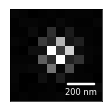

In [41]:
fig, axs = plotter.one_column_plot(height=1, width=1)

axs = plotter.image_plot(axs, image_ATTO488, cbar='off', scalebarsize=200, scalebarlabel='200 nm')
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'ATTO_488_Bayer.svg'), dpi=600, format='svg')
plt.show()

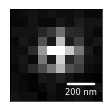

In [42]:
fig, axs = plotter.one_column_plot(height=1, width=1)

axs = plotter.image_plot(axs, image_ATTO565, cbar='off', scalebarsize=200, scalebarlabel='200 nm')
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'ATTO_565_Bayer.svg'), dpi=600, format='svg')
plt.show()

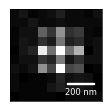

In [43]:
fig, axs = plotter.one_column_plot(height=1, width=1)

axs = plotter.image_plot(axs, image_ATTO647N, cbar='off', scalebarsize=200, scalebarlabel='200 nm')
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'ATTO_647N_Bayer.svg'), dpi=600, format='svg')
plt.show()

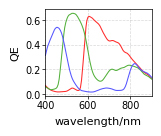

In [44]:
fig, axs = plotter.one_column_plot(height=1.25, width=1.5)

axs = plotter.line_plot(axs, wavelength, R, color='#ff2a2a', xaxislabel='wavelength/nm', yaxislabel='QE')
axs = plotter.line_plot(axs, wavelength, G, color='#53b03b', xaxislabel='wavelength/nm', yaxislabel='QE')
axs = plotter.line_plot(axs, wavelength, B, color='#5555ff', xaxislabel='wavelength/nm', yaxislabel='QE')

axs.set_xlim([400, 900])
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'Bayer_Pixel_Spectra.svg'), dpi=600, format='svg')
plt.show()

In [8]:
image_size = 10
masks_W = M_F.get_masks(size_x=image_size, size_y=image_size, mosaic_unit=np.array([['W', 'W'], ['W', 'W']]))
R_nonsharp = np.max(G) * gaussian_model(wavelength, 650, 500)
G_nonsharp = np.max(G) * gaussian_model(wavelength, 650, 500)
B_nonsharp = np.max(G) * gaussian_model(wavelength, 650, 500)
pixel_QYs_broad = np.vstack([B_nonsharp, G_nonsharp, R_nonsharp])

camera_parameters_dict = {
    "gain": np.full((image_size, image_size), np.median(gain)),
    "offset": np.full((image_size, image_size), np.median(offset)),
    "variance": np.full((image_size, image_size), np.median(variance)),
    "readnoise": np.full((image_size, image_size), np.median(readnoise)),
    "rqe": np.full((image_size, image_size), np.median(rqe)),
    "masks": masks_W,
    "pixel_QYs": pixel_QYs_broad,
    "pixel_order": ["W", "W", "W"],
    "pixel_order_indices": {
        "W": 0,
    },  # Fixed to use dict instead of list
}


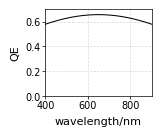

In [11]:
fig, axs = plotter.one_column_plot(height=1.25, width=1.5)

axs = plotter.line_plot(axs, wavelength, R_nonsharp, color='black', xaxislabel='wavelength/nm', yaxislabel='QE')

axs.set_xlim([400, 900])
axs.set_ylim([0, 0.7])
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'Normal_Pixel_Spectra.svg'), dpi=600, format='svg')
plt.show()

In [67]:
dye = "ATTO 488"
n_photons = {}
n_photon = 4000
n_photons[dye] = np.full(1, n_photon)
pixel_size = 69
dye_matrix = np.zeros([1, len(wavelength)])
filters = []
x0y0 = {}
max = pixel_size * image_size

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
NA = 1.49
x0 = 4.75 * pixel_size
y0 = 4.75 * pixel_size
for dye in n_photons:
    x0y0[dye] = np.zeros([1, 2, 1])
    x0y0[dye][:, :, :] = np.array([[y0, x0]]).T

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
n_background = 4
image_ATTO488_W, _, _ = MSF.gen_camera_image_stack(
    camera_parameters_dict,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

In [68]:
dye = "ATTO 565"
n_photons = {}
n_photon = 4000
n_photons[dye] = np.full(1, n_photon)
pixel_size = 69
dye_matrix = np.zeros([1, len(wavelength)])
filters = []
x0y0 = {}
max = pixel_size * image_size

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
NA = 1.49
x0 = 4.75 * pixel_size
y0 = 4.75 * pixel_size
for dye in n_photons:
    x0y0[dye] = np.zeros([1, 2, 1])
    x0y0[dye][:, :, :] = np.array([[y0, x0]]).T

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
n_background = 4
image_ATTO565_W, _, _ = MSF.gen_camera_image_stack(
    camera_parameters_dict,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

In [69]:
dye = "ATTO 647N"
n_photons = {}
n_photon = 4000
n_photons[dye] = np.full(1, n_photon)
pixel_size = 69
dye_matrix = np.zeros([1, len(wavelength)])
filters = []
x0y0 = {}
max = pixel_size * image_size

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
NA = 1.49
x0 = 4.75 * pixel_size
y0 = 4.75 * pixel_size
for dye in n_photons:
    x0y0[dye] = np.zeros([1, 2, 1])
    x0y0[dye][:, :, :] = np.array([[y0, x0]]).T

average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(
        dye, filters, wavelength, camera_parameters_dict["pixel_QYs"]
    )
)
n_background = 4
image_ATTO647N_W, _, _ = MSF.gen_camera_image_stack(
    camera_parameters_dict,
    wavelength,
    np.array(average_emission_wavelengths),
    np.array(dye_pixel_efficiency),
    n_photons,
    x0y0,
    background_photons=n_background,
    smoothing_function=smoothing_function,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=False,
)

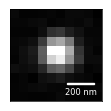

In [71]:
fig, axs = plotter.one_column_plot(height=1, width=1)

axs = plotter.image_plot(axs, image_ATTO488_W, cbar='off', scalebarsize=200, scalebarlabel='200 nm')
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'ATTO_488_W.svg'), dpi=600, format='svg')
plt.show()

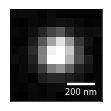

In [72]:
fig, axs = plotter.one_column_plot(height=1, width=1)

axs = plotter.image_plot(axs, image_ATTO565_W, cbar='off', scalebarsize=200, scalebarlabel='200 nm')
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'ATTO_565_W.svg'), dpi=600, format='svg')
plt.show()

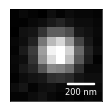

In [73]:
fig, axs = plotter.one_column_plot(height=1, width=1)

axs = plotter.image_plot(axs, image_ATTO647N_W, cbar='off', scalebarsize=200, scalebarlabel='200 nm')
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/'
plt.savefig(os.path.join(folder, 'ATTO_647N_W.svg'), dpi=600, format='svg')
plt.show()